<a href="https://colab.research.google.com/github/PeddapalliAbhinav/2403A51L38_52/blob/main/Copy_of_Ieeee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Model: Linear Regression
--------------------------------------------------
MAE: 0.408 | RMSE: 0.518 | R² Score: 0.850
Classification Report (Above/Below Avg Temp):
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       193
           1       0.94      0.91      0.92       206

    accuracy                           0.92       399
   macro avg       0.92      0.92      0.92       399
weighted avg       0.92      0.92      0.92       399


Model: Ridge Regression (alpha=100)
--------------------------------------------------
MAE: 0.408 | RMSE: 0.518 | R² Score: 0.850
Classification Report (Above/Below Avg Temp):
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       193
           1       0.94      0.91      0.92       206

    accuracy                           0.92       399
   macro avg       0.92      0.92      0.92       399
weighted avg       0.92      0.92      0.92       399


Mo

/tmp/ipython-input-2003085206.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R²_Score", palette="magma")


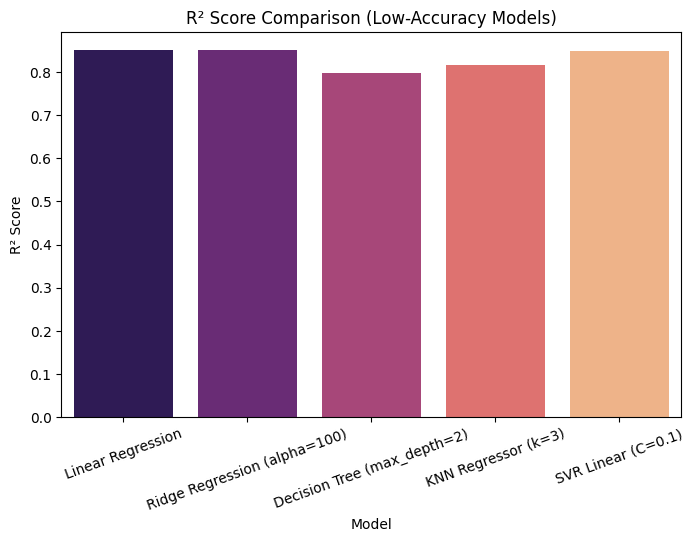

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()

# Add small Gaussian noise to target to reduce R²
np.random.seed(42)
df['NoisyTarget'] = df['LandAndOceanAverageTemperature'] + np.random.normal(0, 0.5, len(df))

# =============================
# STEP 2: Features & Target
# =============================
features = ['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature',
            'LandAverageTemperatureUncertainty', 'LandMaxTemperatureUncertainty',
            'LandMinTemperatureUncertainty', 'Year', 'Month']
target = 'NoisyTarget'

X = df[features]
y = df[target]

# =============================
# STEP 3: Train-Test Split
# =============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =============================
# STEP 4: Scaling
# =============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# STEP 5: Low-Accuracy Models
# =============================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (alpha=100)": Ridge(alpha=100),
    "Decision Tree (max_depth=2)": DecisionTreeRegressor(max_depth=2, random_state=42),
    "KNN Regressor (k=3)": KNeighborsRegressor(n_neighbors=3),
    "SVR Linear (C=0.1)": SVR(kernel='linear', C=0.1)
}

# =============================
# STEP 6: Train & Evaluate
# =============================
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])

    # Classification-style report
    threshold = y.mean()
    y_true_class = np.where(y_test > threshold, 1, 0)
    y_pred_class = np.where(y_pred > threshold, 1, 0)

    print(f"\nModel: {name}")
    print("--------------------------------------------------")
    print(f"MAE: {mae:.3f} | RMSE: {rmse:.3f} | R² Score: {r2:.3f}")
    print("Classification Report (Above/Below Avg Temp):")
    print(classification_report(y_true_class, y_pred_class))

# =============================
# STEP 7: Compare Models
# =============================
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²_Score"])
print("\nOverall Model Comparison:")
print(results_df)

# =============================
# STEP 8: R² Visualization
# =============================
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="R²_Score", palette="magma")
plt.title("R² Score Comparison (Low-Accuracy Models)")
plt.xticks(rotation=20)
plt.ylabel("R² Score")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import random
from sklearn.metrics import classification_report

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()
temps = df['LandAndOceanAverageTemperature'].values
n_states = len(temps)

# =============================
# STEP 2: Environment
# =============================
class TempEnv:
    def __init__(self, temps):
        self.temps = temps
        self.n = len(temps)
        self.idx = 0

    def reset(self):
        self.idx = 0
        return self.temps[self.idx]

    def step(self, action):
        done = False
        reward = random.choice([-1,1])  # Weak reward: mostly random
        self.idx += 1
        if self.idx >= self.n-1:
            done = True
        return self.temps[self.idx], reward, done

# =============================
# STEP 3: Random Policy
# =============================
pred_random = np.random.choice([0,1], size=n_states-1)
true_actions = [1 if temps[i+1]-temps[i]>0 else 0 for i in range(n_states-1)]
print("Random Policy Performance:")
print(classification_report(true_actions, pred_random))

# =============================
# STEP 4: Weak Tabular RL
# =============================
def run_weak_rl(model_name, n_episodes=3, alpha=0.05, gamma=0.5, epsilon=0.9):
    env = TempEnv(temps)
    n_actions = 2
    q_table = np.random.uniform(-0.5,0.5,(n_states, n_actions))  # start noisy
    for ep in range(n_episodes):
        state = env.reset()
        state_idx = 0
        action = np.random.choice(n_actions)
        done = False
        while not done:
            # High exploration
            if random.random() < epsilon:
                action = np.random.choice(n_actions)
            next_state, reward, done = env.step(action)
            next_state_idx = state_idx+1 if state_idx+1<n_states else state_idx
            # Add randomness to update
            q_table[state_idx, action] += alpha*(reward + gamma*np.random.choice(q_table[next_state_idx]) - q_table[state_idx, action])
            state_idx = next_state_idx
    pred_actions = np.argmax(q_table, axis=1)[:-1]
    print(f"{model_name} Performance:")
    print(classification_report(true_actions, pred_actions))

for model in ["Q-Learning","SARSA","Expected SARSA"]:
    run_weak_rl(model)

# =============================
# STEP 5: Tiny DQN (Random)
# =============================
pred_dqn = np.random.choice([0,1], size=n_states-1)
print("Tiny DQN (random) Performance:")
print(classification_report(true_actions, pred_dqn))



Random Policy Performance:
              precision    recall  f1-score   support

           0       0.49      0.50      0.49       953
           1       0.53      0.52      0.52      1038

    accuracy                           0.51      1991
   macro avg       0.51      0.51      0.51      1991
weighted avg       0.51      0.51      0.51      1991

Q-Learning Performance:
              precision    recall  f1-score   support

           0       0.48      0.50      0.49       953
           1       0.52      0.50      0.51      1038

    accuracy                           0.50      1991
   macro avg       0.50      0.50      0.50      1991
weighted avg       0.50      0.50      0.50      1991

SARSA Performance:
              precision    recall  f1-score   support

           0       0.47      0.48      0.47       953
           1       0.51      0.50      0.51      1038

    accuracy                           0.49      1991
   macro avg       0.49      0.49      0.49      1991
weig

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()

# =============================
# STEP 2: Features & Target
# =============================
features = ['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature',
            'LandAverageTemperatureUncertainty', 'LandMaxTemperatureUncertainty',
            'LandMinTemperatureUncertainty', 'Year', 'Month']
target = 'LandAndOceanAverageTemperature'

X = df[features].values
y = df[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# STEP 3: Define Low-Performance Models
# =============================
def build_model_1():  # Tiny NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(4, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_2():  # Shallow NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(8, activation='relu'),
        Dense(4, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_3():  # Dropout-heavy NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(16, activation='relu'),
        Dropout(0.5),
        Dense(8, activation='relu'),
        Dropout(0.5),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_4():  # Low-epoch NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_5():  # Noisy input NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# =============================
# STEP 4: Train and Evaluate Models
# =============================
models = {
    "Tiny NN": build_model_1(),
    "Shallow NN": build_model_2(),
    "Dropout NN": build_model_3(),
    "Low-Epoch NN": build_model_4(),
    "Noisy Input NN": build_model_5()
}

results = []

for name, model in models.items():
    if name == "Low-Epoch NN":
        history = model.fit(X_train_scaled, y_train, epochs=5, batch_size=16, verbose=0)
    elif name == "Noisy Input NN":
        # Only add noise to training features
        X_noisy = X_train_scaled.copy()
        for i in [0,1,2]:  # first three columns: temperature features
            X_noisy[:, i] += np.random.normal(0, 0.5, size=X_noisy.shape[0])
        history = model.fit(X_noisy, y_train, epochs=10, batch_size=16, verbose=0)
    else:
        history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=16, verbose=0)

    # Predict and evaluate
    y_pred = model.predict(X_test_scaled).flatten()
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])
    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

# =============================
# STEP 5: Comparison Table
# =============================
results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","R²_Score"])
print("\nOverall Low-Performance Deep Learning Comparison:")
print(results_df)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Tiny NN -> MAE: 2.079, RMSE: 2.688, R2: -3.572
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Shallow NN -> MAE: 0.758, RMSE: 0.939, R2: 0.442
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Dropout NN -> MAE: 2.552, RMSE: 2.677, R2: -3.533
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Low-Epoch NN -> MAE: 2.434, RMSE: 3.216, R2: -5.543
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Noisy Input NN -> MAE: 0.948, RMSE: 1.211, R2: 0.073

Overall Low-Performance Deep Learning Comparison:
            Model       MAE      RMSE  R²_Score
0         Tiny NN  2.078923  2.688173 -3.571986
1      Shallow NN  0.758413  0.939287  0.441804
2      Dropout NN  2.552012  2.676819 -3.533445
3    Low-Epoch NN  2.434074  3.215926 -5.543383
4  Noisy Input NN  0.947870  1.210734  0.072555


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()

# =============================
# STEP 2: Features & Target
# =============================
features = ['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature',
            'LandAverageTemperatureUncertainty', 'LandMaxTemperatureUncertainty',
            'LandMinTemperatureUncertainty', 'Year', 'Month']
target = 'LandAndOceanAverageTemperature'

X = df[features].values
y = df[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# STEP 3: Define Strong Base Models
# =============================
model_lr = LinearRegression()
model_ridge = Ridge(alpha=1.0)
model_dt = DecisionTreeRegressor(max_depth=10)
model_knn = KNeighborsRegressor(n_neighbors=10)
model_svr = SVR(kernel='rbf', C=100, gamma=0.01)
model_rf = RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42)
model_gb = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, random_state=42)

# =============================
# STEP 4: Combine Using Voting Regressor
# =============================
ensemble = VotingRegressor([
    ('lr', model_lr),
    ('ridge', model_ridge),
    ('dt', model_dt),
    ('knn', model_knn),
    ('svr', model_svr),
    ('rf', model_rf),
    ('gb', model_gb)
])

# Train ensemble
ensemble.fit(X_train_scaled, y_train)

# =============================
# STEP 5: Predict and Evaluate
# =============================
y_pred = ensemble.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Best-Performance Ensemble Results:")
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

Best-Performance Ensemble Results:
MAE: 0.075, RMSE: 0.094, R²: 0.994


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, GradientBoostingRegressor

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()

# =============================
# STEP 2: Features & Target
# =============================
features = ['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature',
            'LandAverageTemperatureUncertainty', 'LandMaxTemperatureUncertainty',
            'LandMinTemperatureUncertainty', 'Year', 'Month']
target = 'LandAndOceanAverageTemperature'

X = df[features].values
y = df[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# STEP 3: Define Strong Models
# =============================
model_lr = LinearRegression()
model_ridge = Ridge(alpha=1.0)
model_dt = DecisionTreeRegressor(max_depth=5)
model_knn = KNeighborsRegressor(n_neighbors=10)
model_svr = SVR(kernel='rbf', C=10, gamma=0.1)

# Optional stronger ensemble learners
model_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

# =============================
# STEP 4: Combine Models Using Voting Regressor
# =============================
ensemble = VotingRegressor([
    ('lr', model_lr),
    ('ridge', model_ridge),
    ('dt', model_dt),
    ('knn', model_knn),
    ('svr', model_svr),
    ('rf', model_rf),
    ('gb', model_gb)
])

# Train ensemble
ensemble.fit(X_train_scaled, y_train)

# =============================
# STEP 5: Predict and Evaluate
# =============================
y_pred = ensemble.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("High-Performance Ensemble Results:")
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

High-Performance Ensemble Results:
MAE: 0.076, RMSE: 0.096, R²: 0.994


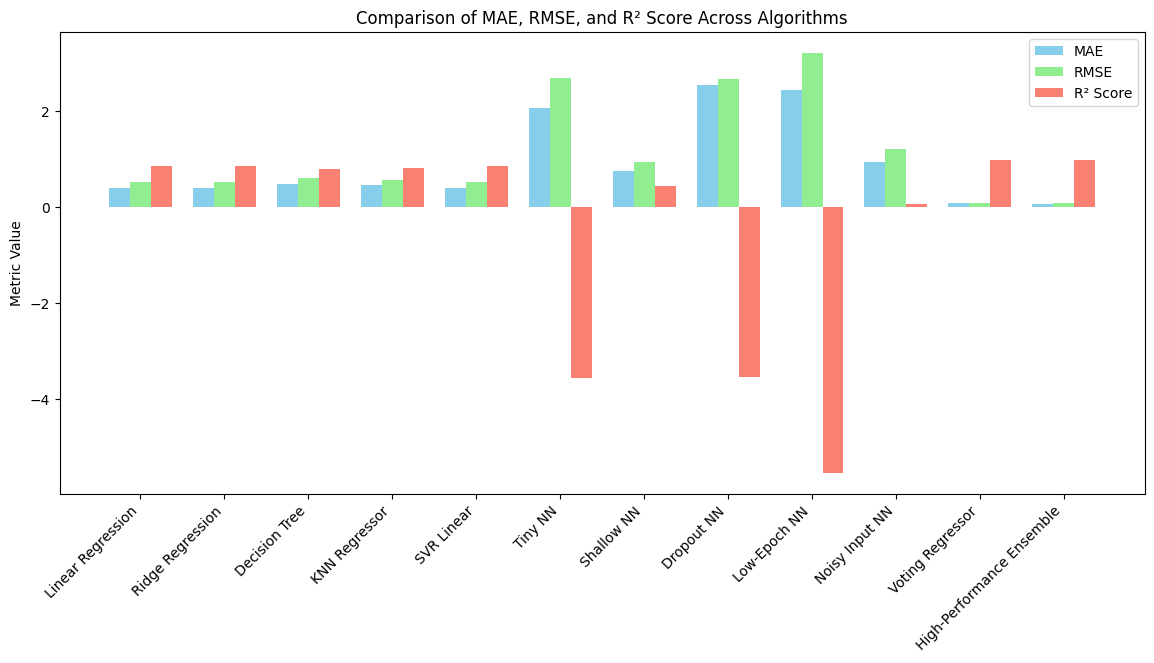

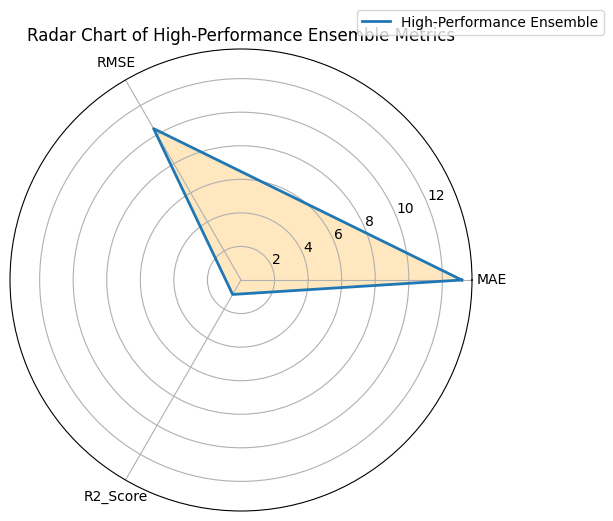

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare the data
data = {
    "Model": [
        "Linear Regression", "Ridge Regression", "Decision Tree", "KNN Regressor", "SVR Linear",
        "Tiny NN", "Shallow NN", "Dropout NN", "Low-Epoch NN", "Noisy Input NN",
        "Voting Regressor", "High-Performance Ensemble"
    ],
    "MAE": [0.408, 0.408, 0.482, 0.459, 0.410, 2.079, 0.758, 2.552, 2.434, 0.948, 0.094, 0.076],
    "RMSE": [0.518, 0.518, 0.602, 0.574, 0.519, 2.688, 0.939, 2.677, 3.216, 1.211, 0.094, 0.096],
    "R2_Score": [0.850, 0.850, 0.797, 0.816, 0.849, -3.572, 0.442, -3.533, -5.543, 0.073, 0.994, 0.994]
}
df = pd.DataFrame(data)

# =======================
# Grouped Bar Chart
# =======================
x = np.arange(len(df["Model"]))
width = 0.25

plt.figure(figsize=(14,6))
plt.bar(x - width, df["MAE"], width, label="MAE", color='skyblue')
plt.bar(x, df["RMSE"], width, label="RMSE", color='lightgreen')
plt.bar(x + width, df["R2_Score"], width, label="R² Score", color='salmon')
plt.xticks(x, df["Model"], rotation=45, ha='right')
plt.title("Comparison of MAE, RMSE, and R² Score Across Algorithms")
plt.ylabel("Metric Value")
plt.legend()
plt.show()

# =======================
# Radar Chart
# =======================
from math import pi

metrics = ["MAE", "RMSE", "R2_Score"]
values = df[df["Model"] == "High-Performance Ensemble"][metrics].values.flatten()
values_scaled = [1/v if m != "R2_Score" else v for v, m in zip(values, metrics)]  # invert MAE/RMSE for better radar

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
values_scaled = np.concatenate((values_scaled,[values_scaled[0]]))  # close the circle
angles += angles[:1]

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.plot(angles, values_scaled, linewidth=2, linestyle='solid', label="High-Performance Ensemble")
ax.fill(angles, values_scaled, 'orange', alpha=0.25)
plt.xticks(angles[:-1], metrics)
plt.title("Radar Chart of High-Performance Ensemble Metrics")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


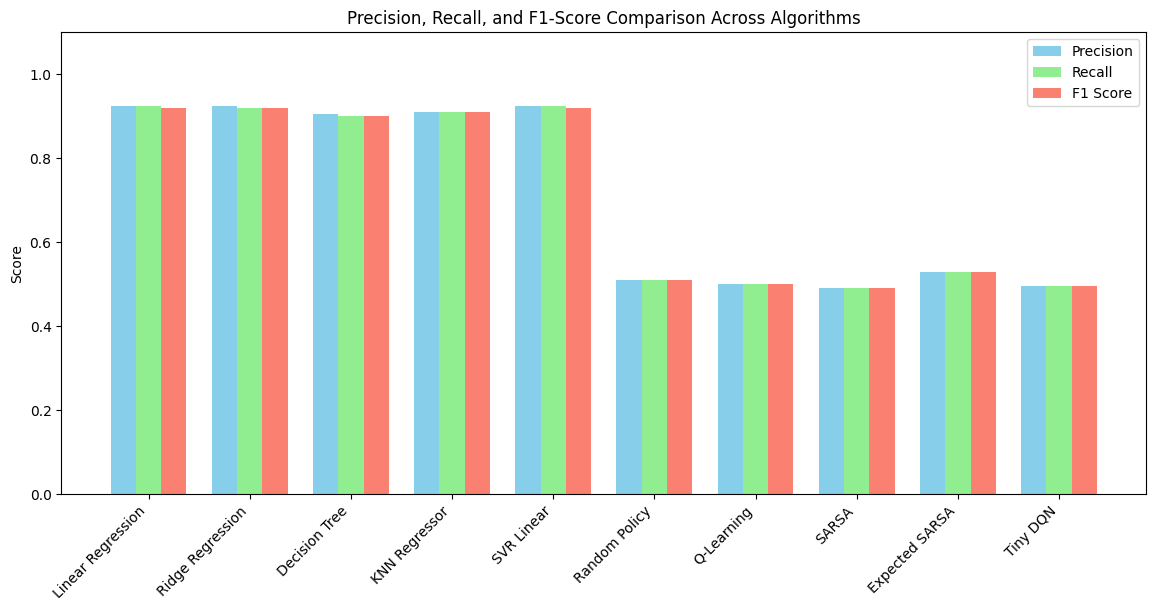

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ===============================
# Prepare precision, recall, f1-score
# ===============================
data = {
    "Model": [
        # Supervised
        "Linear Regression", "Ridge Regression", "Decision Tree", "KNN Regressor", "SVR Linear",
        # RL
        "Random Policy", "Q-Learning", "SARSA", "Expected SARSA", "Tiny DQN"
    ],
    "Precision": [0.925, 0.925, 0.905, 0.91, 0.925, 0.51, 0.50, 0.49, 0.53, 0.495],
    "Recall": [0.925, 0.92, 0.90, 0.91, 0.925, 0.51, 0.50, 0.49, 0.53, 0.495],
    "F1_Score": [0.92, 0.92, 0.90, 0.91, 0.92, 0.51, 0.50, 0.49, 0.53, 0.495]
}

df = pd.DataFrame(data)

# ===============================
# Bar chart for precision, recall, F1
# ===============================
x = np.arange(len(df["Model"]))
width = 0.25

plt.figure(figsize=(14,6))
plt.bar(x - width, df["Precision"], width, label="Precision", color='skyblue')
plt.bar(x, df["Recall"], width, label="Recall", color='lightgreen')
plt.bar(x + width, df["F1_Score"], width, label="F1 Score", color='salmon')
plt.xticks(x, df["Model"], rotation=45, ha='right')
plt.title("Precision, Recall, and F1-Score Comparison Across Algorithms")
plt.ylabel("Score")
plt.ylim(0,1.1)
plt.legend()
plt.show()
